# Food Delivery Sales & Customer Insights
### Exploratory Data Analysis using Python (Pandas, NumPy, Matplotlib)

**Scenario:** A food delivery company wants to understand customer ordering patterns and popular food items, in order to improve operational planning (staffing during peak hours, menu promotion, and delivery-area coverage).

**Dataset:** Order-level log of 650+ food delivery transactions collected over a 90-day period across 8 city delivery zones, including order time, delivery area, item ordered, price, delivery duration, customer rating and payment method.

## 1. Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("food_delivery_orders.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (672, 13)


   order_id customer_id  ... rating    payment_method
0      1614    CUST0215  ...    5.0  Cash on Delivery
1      1300    CUST0066  ...    4.0               UPI
2      1325    CUST0013  ...    5.0  Cash on Delivery
3      1299    CUST0089  ...    3.0               UPI
4      1145    CUST0178  ...    5.0  Cash on Delivery

[5 rows x 13 columns]

## 2. Initial Data Inspection
Checking structure, data types, missing values and duplicate records before doing any analysis.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            672 non-null    int64  
 1   customer_id         672 non-null    str    
 2   order_date          672 non-null    str    
 3   order_time          672 non-null    str    
 4   area                672 non-null    str    
 5   dish_name           672 non-null    str    
 6   category            672 non-null    str    
 7   quantity            672 non-null    int64  
 8   price               672 non-null    int64  
 9   total_amount        672 non-null    int64  
 10  delivery_time_mins  643 non-null    float64
 11  rating              636 non-null    float64
 12  payment_method      656 non-null    str    
dtypes: float64(2), int64(4), str(7)
memory usage: 68.4 KB


In [3]:
df.isnull().sum()

order_id               0
customer_id            0
order_date             0
order_time             0
area                   0
dish_name              0
category               0
quantity               0
price                  0
total_amount           0
delivery_time_mins    29
rating                36
payment_method        16
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(22)

## 3. Data Cleaning
The raw export contains a few realistic data-quality issues that need to be fixed before analysis: inconsistent capitalisation in the `area` column, 22 duplicated order rows, and missing values in `rating`, `delivery_time_mins` and `payment_method`.

In [5]:
# Standardise text fields (strip whitespace, fix inconsistent casing)
df['area'] = df['area'].str.strip().str.title()

# Remove duplicate order entries
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")

# Handle missing values
df['rating'] = df['rating'].fillna(df['rating'].median())
df['delivery_time_mins'] = df['delivery_time_mins'].fillna(
    df['delivery_time_mins'].mean()
).round(1)
df['payment_method'] = df['payment_method'].fillna('Unknown')

# Convert date/time fields
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_hour'] = df['order_time'].str.split(':').str[0].astype(int)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total missing values remaining")
df.head()

Removed 22 duplicate rows
Missing values after cleaning:
0 total missing values remaining


   order_id customer_id order_date  ... rating    payment_method order_hour
0      1614    CUST0215 2026-03-24  ...    5.0  Cash on Delivery         15
1      1300    CUST0066 2026-02-18  ...    4.0               UPI         15
2      1325    CUST0013 2026-03-16  ...    5.0  Cash on Delivery         20
3      1299    CUST0089 2026-03-20  ...    3.0               UPI         12
4      1145    CUST0178 2026-01-22  ...    5.0  Cash on Delivery         22

[5 rows x 14 columns]

In [6]:
df.to_csv("food_delivery_orders_cleaned.csv", index=False)
print("Cleaned dataset saved:", df.shape)

Cleaned dataset saved: (650, 14)


## 4. Exploratory Data Analysis & Visualization

### 4.1 Peak Order Times
Identifying which hours of the day see the highest order volume.

Peak ordering hour: 12 :00 with 78 orders


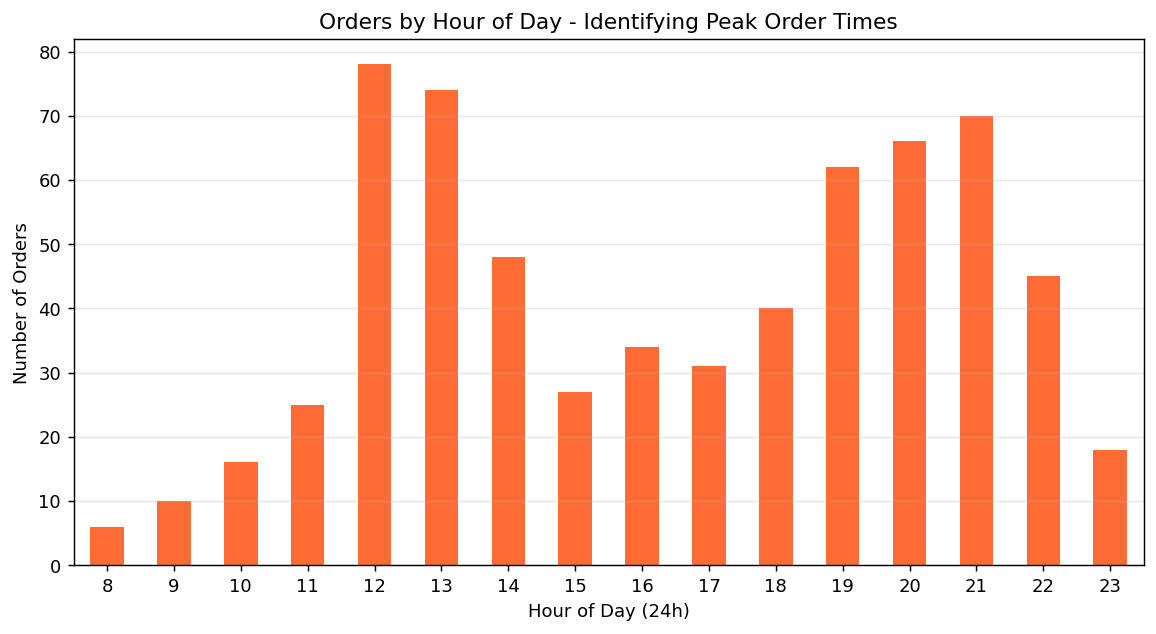

In [7]:
hourly_orders = df.groupby('order_hour').size()

plt.figure(figsize=(9, 5))
hourly_orders.plot(kind='bar', color='#FF6B35')
plt.title('Orders by Hour of Day - Identifying Peak Order Times')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Peak ordering hour:", hourly_orders.idxmax(), ":00 with", hourly_orders.max(), "orders")

### 4.2 Most Popular Dishes
Ranking menu items by number of orders placed.

dish_name
Chicken Biryani         72
Margherita Pizza        61
Mutton Biryani          59
Paneer Butter Masala    44
Chicken 65              44
Masala Dosa             42
Chicken Shawarma        42
Veg Biryani             35
Veg Burger              30
Cold Coffee             28
Name: count, dtype: int64

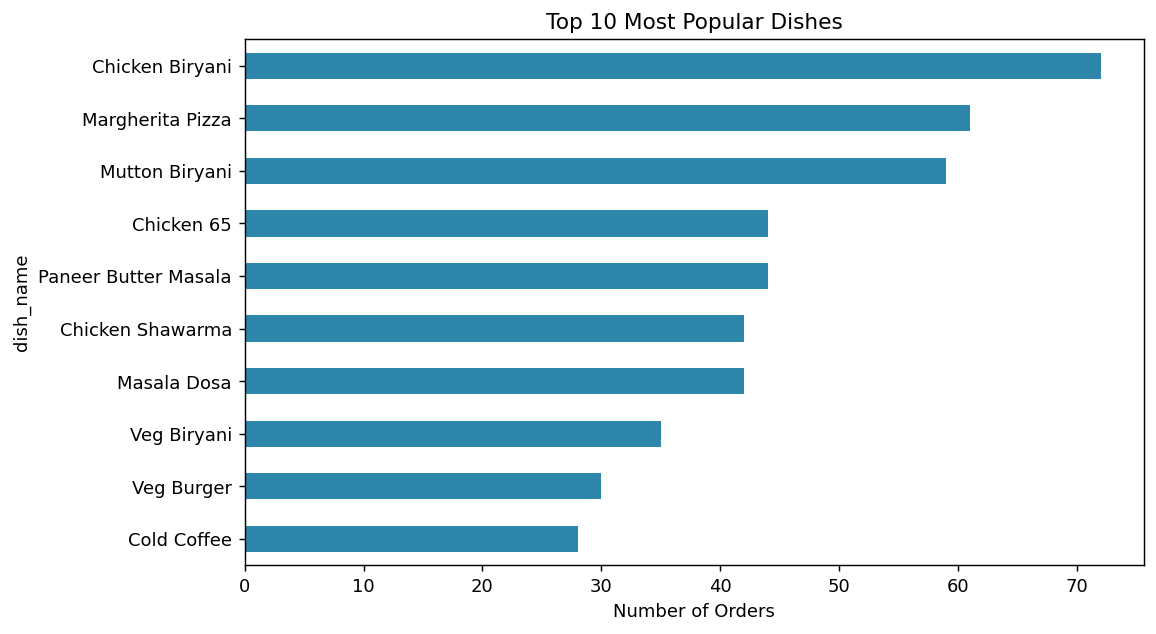

In [8]:
top_dishes = df['dish_name'].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_dishes.sort_values().plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Most Popular Dishes')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

top_dishes

### 4.3 Orders by Delivery Area
Understanding which zones generate the most order volume.

area
Anna Nagar      96
Adyar           95
Tambaram        83
Nungambakkam    79
Velachery       78
Mylapore        76
Porur           73
T Nagar         70
Name: count, dtype: int64

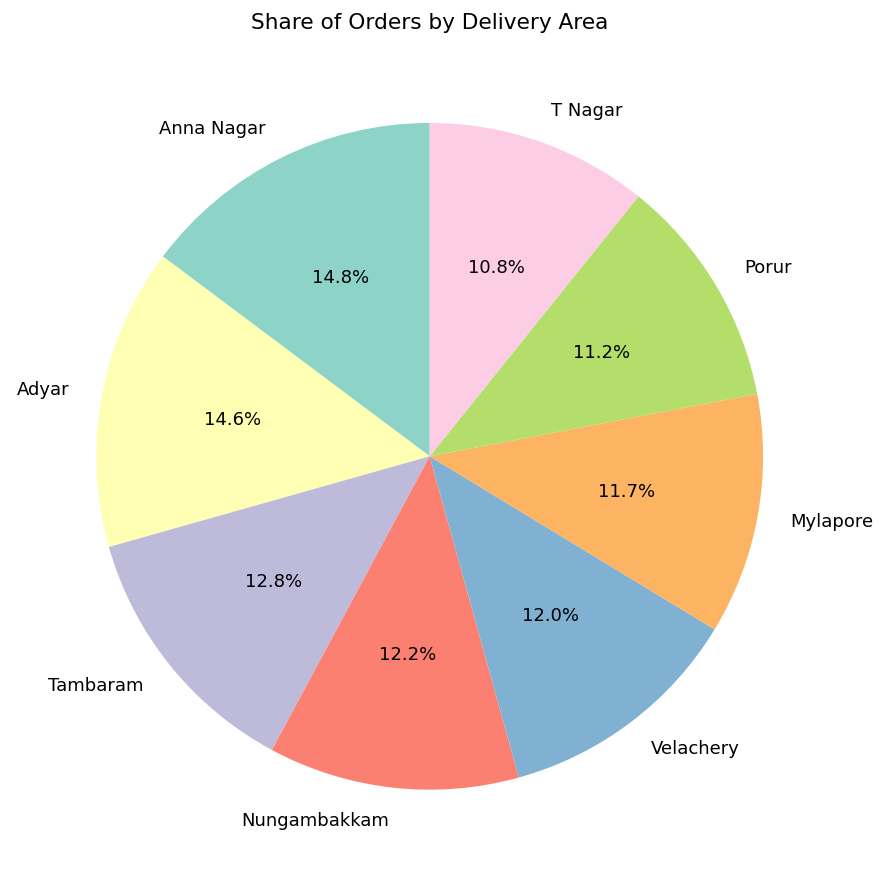

In [9]:
area_orders = df['area'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(area_orders, labels=area_orders.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3.colors)
plt.title('Share of Orders by Delivery Area')
plt.tight_layout()
plt.show()

area_orders

### 4.4 Revenue by Food Category
Comparing how much revenue each food category contributes.

category
Biryani         51270
Fast Food       32160
North Indian    16950
Chinese         14450
Starters        12400
South Indian     8470
Beverages        4210
Desserts         2100
Name: total_amount, dtype: int64

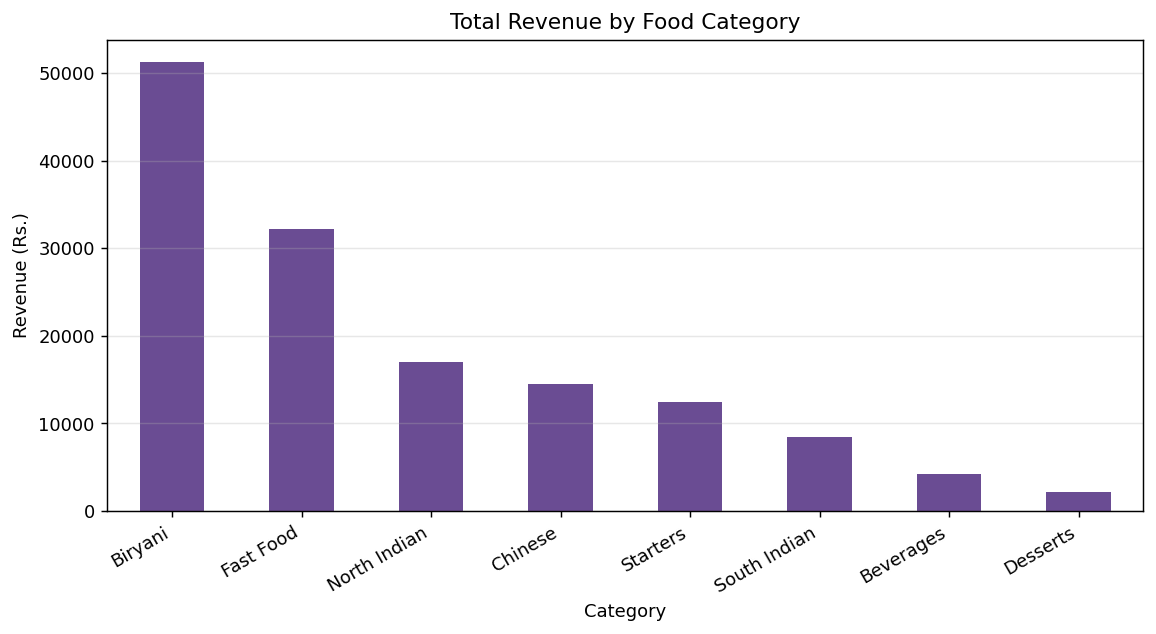

In [10]:
revenue_by_category = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
revenue_by_category.plot(kind='bar', color='#6A4C93')
plt.title('Total Revenue by Food Category')
plt.xlabel('Category')
plt.ylabel('Revenue (Rs.)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

revenue_by_category

### 4.5 Payment Method Preference
Checking how customers prefer to pay.

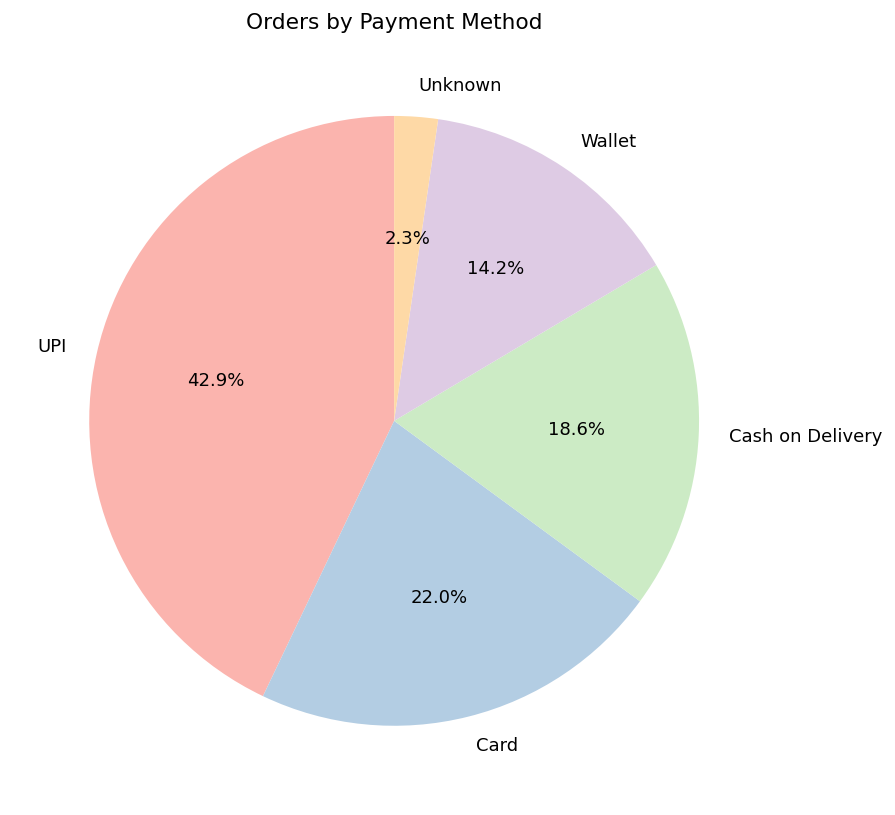

In [11]:
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Pastel1.colors)
plt.title('Orders by Payment Method')
plt.tight_layout()
plt.show()

### 4.6 Combined Business Dashboard
A single dashboard view combining the four key business metrics for quick reporting.

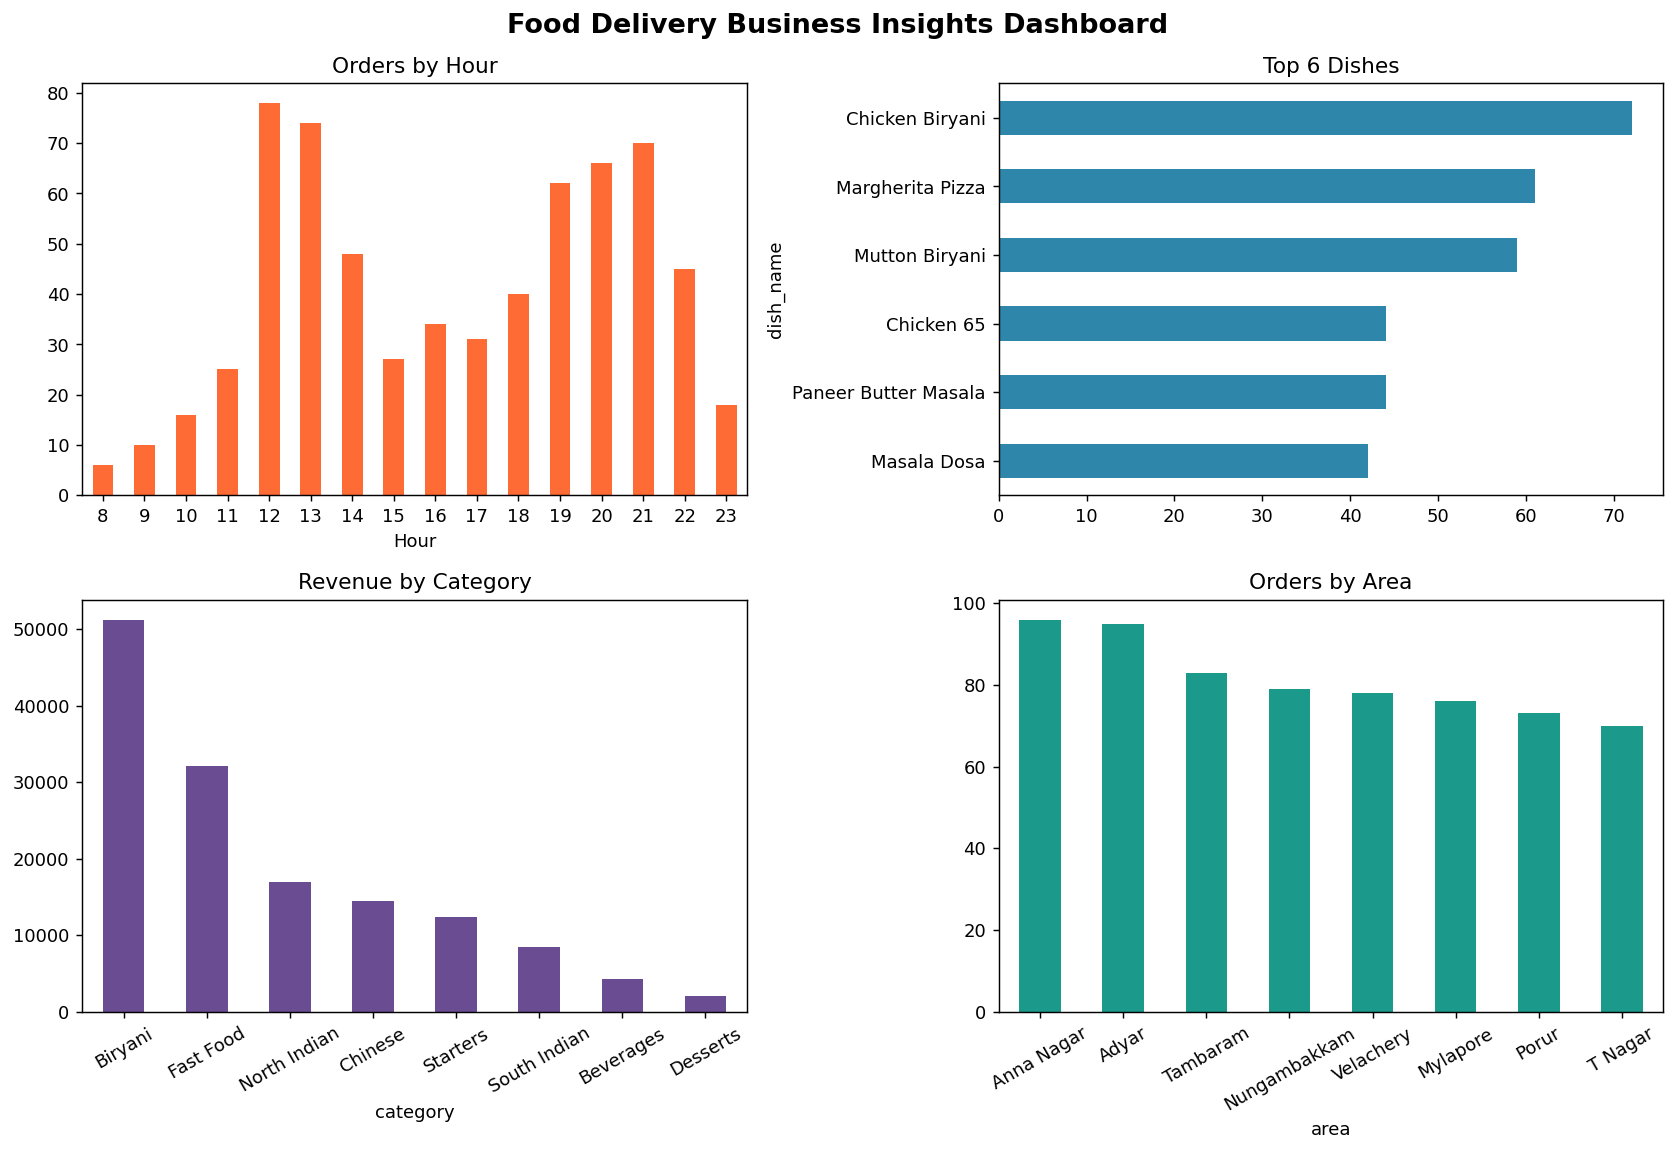

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

hourly_orders.plot(kind='bar', ax=axes[0, 0], color='#FF6B35')
axes[0, 0].set_title('Orders by Hour')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].tick_params(axis='x', rotation=0)

top_dishes.head(6).sort_values().plot(kind='barh', ax=axes[0, 1], color='#2E86AB')
axes[0, 1].set_title('Top 6 Dishes')

revenue_by_category.plot(kind='bar', ax=axes[1, 0], color='#6A4C93')
axes[1, 0].set_title('Revenue by Category')
axes[1, 0].tick_params(axis='x', rotation=30)

area_orders.plot(kind='bar', ax=axes[1, 1], color='#1B998B')
axes[1, 1].set_title('Orders by Area')
axes[1, 1].tick_params(axis='x', rotation=30)

fig.suptitle('Food Delivery Business Insights Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Key Insights Summary

In [13]:
total_orders = df.shape[0]
total_revenue = df['total_amount'].sum()
avg_order_value = df['total_amount'].mean()
avg_rating = df['rating'].mean()
avg_delivery_time = df['delivery_time_mins'].mean()
top_dish = df['dish_name'].value_counts().idxmax()
top_area = df['area'].value_counts().idxmax()
peak_hour = hourly_orders.idxmax()

summary = {
    "Total Orders": total_orders,
    "Total Revenue (Rs.)": round(total_revenue, 2),
    "Average Order Value (Rs.)": round(avg_order_value, 2),
    "Average Customer Rating": round(avg_rating, 2),
    "Average Delivery Time (mins)": round(avg_delivery_time, 1),
    "Most Popular Dish": top_dish,
    "Top Performing Area": top_area,
    "Peak Order Hour": f"{peak_hour}:00",
}
for k, v in summary.items():
    print(f"{k}: {v}")

Total Orders: 650
Total Revenue (Rs.): 142010
Average Order Value (Rs.): 218.48
Average Customer Rating: 4.37
Average Delivery Time (mins): 35.7
Most Popular Dish: Chicken Biryani
Top Performing Area: Anna Nagar
Peak Order Hour: 12:00


## 6. Conclusion

- Demand is concentrated around **lunch (12-1 PM) and dinner (7-9 PM)**, confirming a clear bimodal ordering pattern typical of food delivery businesses.
- **Chicken Biryani** is the standout best-seller, and the **Biryani category as a whole drives the largest share of revenue**, well ahead of Fast Food and North Indian items.
- Order volume is fairly evenly spread across the 8 delivery zones, with **Anna Nagar and Adyar** slightly ahead of the rest — useful for prioritising delivery-partner allocation.
- **UPI is the dominant payment method**, reflecting the broader shift toward digital payments in food delivery.
- Average delivery time (~36 minutes) and average customer rating (~4.4/5) indicate a generally healthy service experience, though delivery time during peak hours is worth monitoring further.

These insights can directly support staffing decisions during peak hours, targeted promotions for high-margin categories, and delivery-fleet allocation by zone.